# 🌿 AquaVidarbha — XGBoost Temporal Engine (Lag-Free)
## Groundwater Depth Prediction | Vidarbha, Maharashtra, India

---

### 📌 Problem Statement
Predict groundwater depth (`depth_mbgl`) using a lag-free feature set, classify risk levels, and save a Colab-friendly model pipeline to Google Drive.

---

### 🌲 Why XGBoost?

| Criterion | Detail |
|---|---|
| **Model Type** | Gradient boosting over decision trees |
| **Handles Non-Linearity** | Excellent for mixed tabular signals |
| **Feature Importance** | Native gain importance + permutation importance |
| **Training Speed** | Fast histogram-based training with `tree_method='hist'` |
| **Missing Values** | Stable with train-only imputation |
| **Temporal Data** | Works well with a strict chronological split |

---

### 📊 Feature Categories

| Category | Features |
|---|---|
| **Meteorological** | `rainfall_mm`, `temperature_avg`, `temperature_max_c`, `temperature_min_c`, `humidity`, `evapotranspiration`, `evapotranspiration_mm` |
| **Soil & Hydrology** | `soil_moisture_index`, `runoff_mm`, `baseflow_mm`, `soil_type_encoded` |
| **Rolling Statistics** | `rainfall_rolling_3m`, `rainfall_rolling_6m` |
| **Stress Indicators** | `rainfall_deficit`, `cumulative_deficit`, `temp_rainfall_ratio`, `drought_index`, `irrigation_demand_mm`, `water_stress_index` |
| **Temporal** | `month`, `season_encoded`, `season`, `month_sin`, `month_cos` |
| **Geospatial** | `latitude`, `longitude`, `elevation_m`, `slope_degree`, `district_encoded` |
| **Vegetation** | `ndvi` |
| **Engineered** | `rainfall_x_soilmoist` |

## 📦 Step 1 — Import Libraries & Configure Environment

In [1]:
import os
import json
import time
import warnings
import hashlib
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_val_score, learning_curve

try:
    from google.colab import drive  # type: ignore
    try:
        drive.mount('/content/drive')
    except Exception:
        pass
except Exception:
    pass

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NOTEBOOK_ROOT = Path.cwd()
BASE_CANDIDATES = []
if os.environ.get('GROUNDWATER_BASE_PATH'):
    BASE_CANDIDATES.append(Path(os.environ['GROUNDWATER_BASE_PATH']))
BASE_CANDIDATES.extend([
    Path('/content/drive/MyDrive/WPS_PRO'),
    Path('/content/drive/MyDrive/Ground_Water_Detection'),
    NOTEBOOK_ROOT,
    NOTEBOOK_ROOT.parent,
])

def first_existing_path(candidates):
    for candidate in candidates:
        if str(candidate).strip() and candidate.exists():
            return candidate
    for candidate in candidates:
        if str(candidate).strip():
            return candidate
    raise FileNotFoundError('No valid path candidates were provided.')

BASE_PATH = first_existing_path(BASE_CANDIDATES)
DATA_CANDIDATES = [
    BASE_PATH / 'Dataset' / 'training_ready_data' / 'vidarbha_groundwater_model_ready.csv',
    BASE_PATH / 'dataset' / 'vidarbha_groundwater_model_ready.csv',
    BASE_PATH / 'data' / 'vidarbha_groundwater_model_ready.csv',
    BASE_PATH / 'data' / 'vidarbha_groundwater_extended_v2.csv',
    NOTEBOOK_ROOT.parent / 'data' / 'vidarbha_groundwater_model_ready.csv',
    NOTEBOOK_ROOT.parent / 'data' / 'vidarbha_groundwater_extended_v2.csv',
]
OUTPUT_CANDIDATES = [
    BASE_PATH / 'Models' / 'engines' / 'path1_temporal' / 'outputs' / 'xgboost_no_lag',
    BASE_PATH / 'outputs' / 'xgboost_no_lag',
    NOTEBOOK_ROOT / 'outputs' / 'xgboost_no_lag',
]
MODEL_CANDIDATES = [
    BASE_PATH / 'Models' / 'engines' / 'path1_temporal' / 'saved_models',
    BASE_PATH / 'saved_models',
    NOTEBOOK_ROOT / 'saved_models',
]
DATA_PATH = first_existing_path(DATA_CANDIDATES)
OUTPUT_DIR = first_existing_path(OUTPUT_CANDIDATES)
MODEL_DIR = first_existing_path(MODEL_CANDIDATES)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ Environment ready')
print(f'BASE_PATH  : {BASE_PATH}')
print(f'DATA_PATH  : {DATA_PATH}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'MODEL_DIR  : {MODEL_DIR}')
print(f'XGBoost    : {xgb.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Notebook started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Mounted at /content/drive
✅ Environment ready
BASE_PATH  : /content/drive/MyDrive/WPS_PRO
DATA_PATH  : /content/drive/MyDrive/WPS_PRO/dataset/vidarbha_groundwater_model_ready.csv
OUTPUT_DIR : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/xgboost_no_lag
MODEL_DIR  : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models
XGBoost    : 3.2.0
Pandas     : 2.2.2
NumPy      : 2.0.2
Notebook started: 2026-05-07 14:16:14


---
## 📂 Step 2 — Load Dataset & Initial Exploration

DATASET LOADED SUCCESSFULLY
Shape: 83,850 rows × 26 columns
Target mean   : 61.86
Target median : 43.06
Target std    : 58.65
Target range  : [0.50, 279.83]
District IDs  : 11 unique values
Total missing values: 0


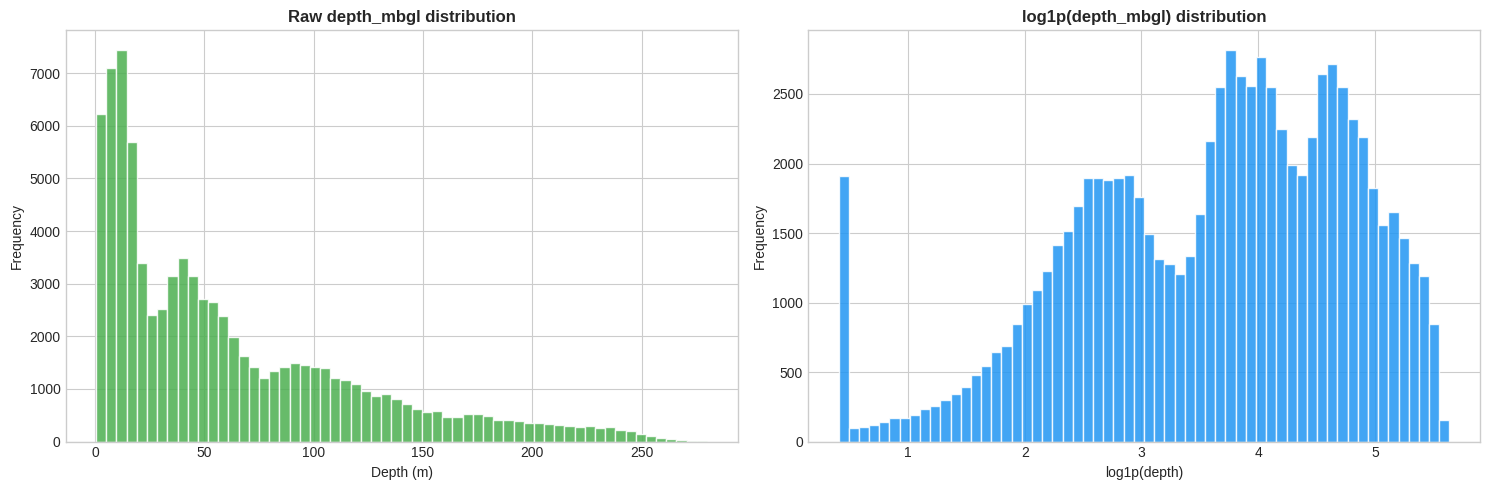

✅ Target distribution plot saved


In [2]:
df = pd.read_csv(DATA_PATH)
df = df.reset_index(drop=True)

if 'date' in df.columns:
    date_series = pd.to_datetime(df['date'], errors='coerce')
    if date_series.notna().any():
        df = df.assign(date=date_series).sort_values('date').reset_index(drop=True)

TARGET = 'depth_mbgl'
if TARGET not in df.columns:
    raise ValueError(f'Target column {TARGET!r} not found in dataset.')

print('=' * 72)
print('DATASET LOADED SUCCESSFULLY')
print('=' * 72)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Target mean   : {df[TARGET].mean():.2f}')
print(f'Target median : {df[TARGET].median():.2f}')
print(f'Target std    : {df[TARGET].std():.2f}')
print(f'Target range  : [{df[TARGET].min():.2f}, {df[TARGET].max():.2f}]')
if 'district_encoded' in df.columns:
    print(f"District IDs  : {df['district_encoded'].nunique()} unique values")

missing_total = int(df.isnull().sum().sum())
print(f'Total missing values: {missing_total}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df[TARGET], bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('Raw depth_mbgl distribution', fontweight='bold')
axes[0].set_xlabel('Depth (m)')
axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(df[TARGET]), bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].set_title('log1p(depth_mbgl) distribution', fontweight='bold')
axes[1].set_xlabel('log1p(depth)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Target distribution plot saved')

---
## 🔧 Step 3 — Feature Selection & Target Transform

In [3]:
DROP_COLUMNS = {'well_id', 'date', 'district', 'year'}
LEAKY_COLUMNS = {'depth_change_rate'}

if 'rainfall_mm' in df.columns and 'soil_moisture_index' in df.columns:
    df['rainfall_x_soilmoist'] = df['rainfall_mm'] * df['soil_moisture_index']

FEATURE_CANDIDATES = [
    'rainfall_mm', 'temperature_avg', 'temperature_max_c', 'temperature_min_c', 'humidity', 'evapotranspiration', 'evapotranspiration_mm',
    'soil_moisture_index', 'runoff_mm', 'baseflow_mm', 'soil_type_encoded',
    'rainfall_rolling_3m', 'rainfall_rolling_6m',
    'rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'drought_index', 'irrigation_demand_mm', 'water_stress_index',
    'month', 'season_encoded', 'season', 'month_sin', 'month_cos',
    'latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded',
    'ndvi', 'rainfall_x_soilmoist',
]

exclude = set(DROP_COLUMNS) | set(LEAKY_COLUMNS) | {TARGET}
for column in df.columns:
    lower = column.lower()
    if 'lag' in lower or lower.startswith('depth_rolling'):
        exclude.add(column)

FEATURES = [column for column in FEATURE_CANDIDATES if column in df.columns and column not in exclude]
if not FEATURES:
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    FEATURES = [column for column in numeric_columns if column not in exclude]

if not FEATURES:
    raise ValueError('No usable features were found after excluding lag and leakage columns.')

X = df[FEATURES].copy()
y_raw = df[TARGET].copy()
y = np.log1p(y_raw)

print(f'Target: {TARGET}')
print(f'Feature count: {len(FEATURES)}')
print('Features used:')
for idx, feature in enumerate(FEATURES, start=1):
    print(f'  [{idx:02d}] {feature}')
print(f'Raw target mean  : {y_raw.mean():.2f}')
print(f'Log target mean  : {y.mean():.4f}')

Target: depth_mbgl
Feature count: 20
Features used:
  [01] rainfall_mm
  [02] temperature_avg
  [03] humidity
  [04] evapotranspiration
  [05] soil_moisture_index
  [06] soil_type_encoded
  [07] rainfall_rolling_3m
  [08] rainfall_rolling_6m
  [09] rainfall_deficit
  [10] cumulative_deficit
  [11] temp_rainfall_ratio
  [12] month
  [13] season_encoded
  [14] latitude
  [15] longitude
  [16] elevation_m
  [17] slope_degree
  [18] district_encoded
  [19] ndvi
  [20] rainfall_x_soilmoist
Raw target mean  : 61.86
Log target mean  : 3.5986


---
## ✂️ Step 4 — Temporal Train / Validation / Test Split

In [4]:
n = len(df)
train_end = int(n * 0.75)
val_end = int(n * 0.875)

train_mask = df.index < train_end
val_mask = (df.index >= train_end) & (df.index < val_end)
test_mask = df.index >= val_end

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_val, y_val = X.loc[val_mask].copy(), y.loc[val_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()

y_train_raw = y_raw.loc[train_mask].copy()
y_val_raw = y_raw.loc[val_mask].copy()
y_test_raw = y_raw.loc[test_mask].copy()

train_medians = X_train.median(numeric_only=True)
for split_name, X_split in [('Train', X_train), ('Val', X_val), ('Test', X_test)]:
    X_split.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_split.fillna(train_medians, inplace=True)
    print(f'{split_name:<5}: {len(X_split):,} rows')

print(f'Train end index : {train_end}')
print(f'Val end index   : {val_end}')
print(f'Total rows      : {n:,}')

Train: 62,887 rows
Val  : 10,481 rows
Test : 10,482 rows
Train end index : 62887
Val end index   : 73368
Total rows      : 83,850


---
## 📈 Step 5 — Correlation & Mutual Information Analysis

Top correlations:
longitude             -0.4617
rainfall_rolling_6m   -0.3721
elevation_m            0.3318
temperature_avg        0.2151
evapotranspiration     0.1750
rainfall_rolling_3m   -0.1630
month                 -0.1598
district_encoded      -0.1148
soil_type_encoded      0.1032
temp_rainfall_ratio    0.0984

Top mutual information scores:
latitude              0.8932
elevation_m           0.8817
slope_degree          0.8743
longitude             0.8273
district_encoded      0.1813
rainfall_rolling_6m   0.1212
month                 0.1153
temperature_avg       0.0732
season_encoded        0.0687
humidity              0.0540


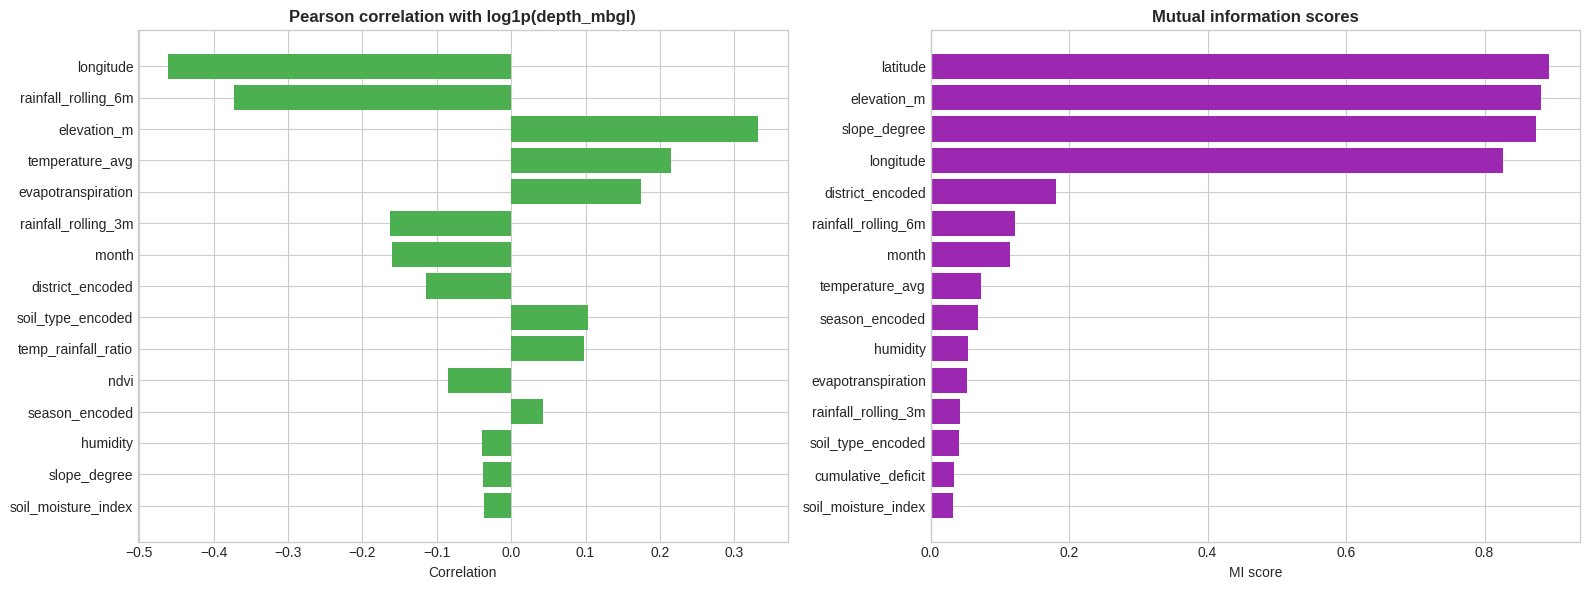

✅ Feature analysis plot saved
Training baseline XGBoost model...
[0]	validation_0-rmse:1.15114
[100]	validation_0-rmse:1.08067
[200]	validation_0-rmse:1.12107
[300]	validation_0-rmse:1.13397
[400]	validation_0-rmse:1.13987
[499]	validation_0-rmse:1.14161
Training time: 5.4s
Baseline train: {'r2': 0.9882990613970115, 'rmse': 5.6698887984520985, 'mae': 3.4163990660028563, 'mdape': 6.278663477235527}
Baseline val  : {'r2': -0.1333749811314222, 'rmse': 70.8174132792718, 'mae': 51.49595955699983, 'mdape': 64.54780241563157}
Baseline test : {'r2': -0.38909807190055035, 'rmse': 86.818140299442, 'mae': 61.83503270692203, 'mdape': 72.70791117755284}


In [5]:
corr_df = X_train.copy()
corr_df[TARGET] = y_train
correlations = corr_df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
mi_scores = mutual_info_regression(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=FEATURES).sort_values(ascending=False)

print('Top correlations:')
print(correlations.head(10).to_string())
print('\nTop mutual information scores:')
print(mi_series.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_corr = correlations.head(min(15, len(correlations)))
axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color='#4CAF50')
axes[0].set_title('Pearson correlation with log1p(depth_mbgl)', fontweight='bold')
axes[0].set_xlabel('Correlation')
top_mi = mi_series.head(min(15, len(mi_series)))
axes[1].barh(top_mi.index[::-1], top_mi.values[::-1], color='#9C27B0')
axes[1].set_title('Mutual information scores', fontweight='bold')
axes[1].set_xlabel('MI score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature analysis plot saved')


def inverse_transform(values):
    return np.clip(np.expm1(values), 0, None)


def evaluate_predictions(y_true_raw, y_pred_raw):
    return {
        'r2': float(r2_score(y_true_raw, y_pred_raw)),
        'rmse': float(np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))),
        'mae': float(mean_absolute_error(y_true_raw, y_pred_raw)),
        'mdape': float(np.median(np.abs((y_true_raw - y_pred_raw) / np.clip(y_true_raw, 1.0, None))) * 100),
    }

baseline_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    objective='reg:squarederror',
    eval_metric='rmse',
)

print('Training baseline XGBoost model...')
t0 = time.time()
baseline_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
print(f'Training time: {time.time() - t0:.1f}s')

y_train_pred = inverse_transform(baseline_model.predict(X_train))
y_val_pred = inverse_transform(baseline_model.predict(X_val))
y_test_pred = inverse_transform(baseline_model.predict(X_test))

baseline_train = evaluate_predictions(y_train_raw.values, y_train_pred)
baseline_val = evaluate_predictions(y_val_raw.values, y_val_pred)
baseline_test = evaluate_predictions(y_test_raw.values, y_test_pred)

print('Baseline train:', baseline_train)
print('Baseline val  :', baseline_val)
print('Baseline test :', baseline_test)

---
## 🔁 Step 6 — Hyperparameter Tuning with RandomizedSearchCV

Running randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Search time: 6.9 minutes
Best CV R²: -0.0273
Best params:
  subsample: 0.8
  reg_lambda: 0.5
  reg_alpha: 0.5
  n_estimators: 500
  min_child_weight: 7
  max_depth: 4
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.6


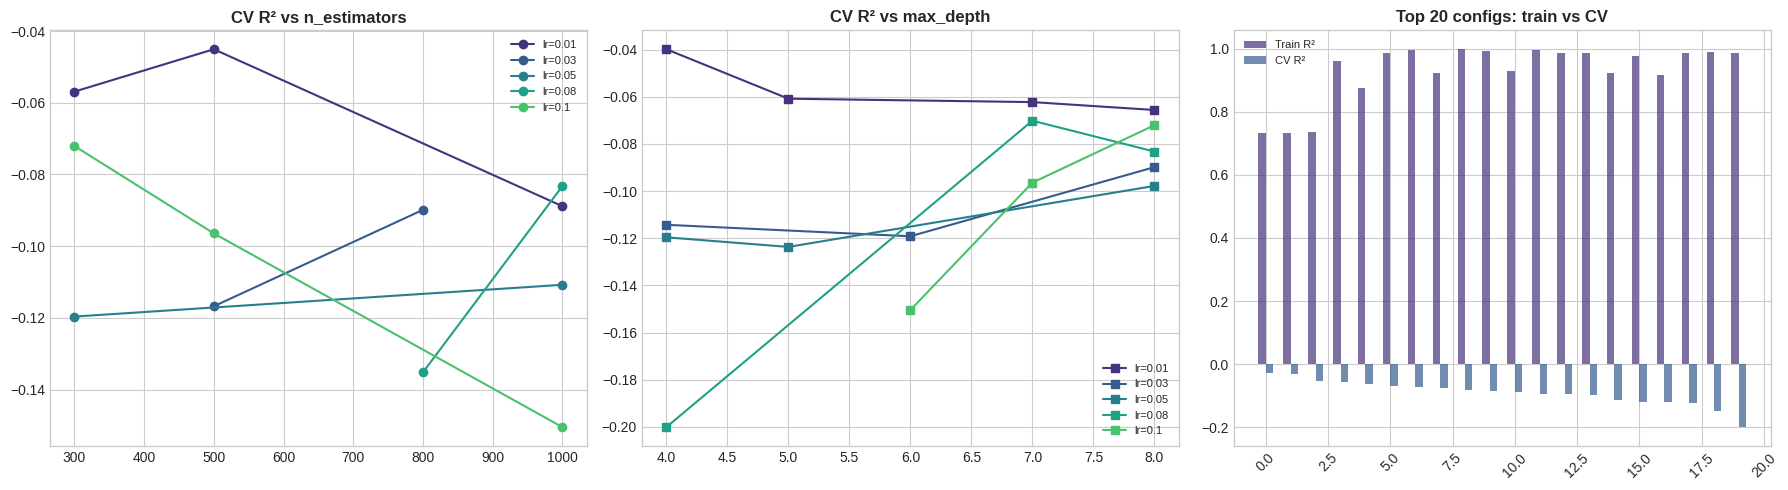

✅ Search results plot saved


In [6]:
param_distributions = {
    'n_estimators': [300, 500, 800, 1000],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7, 10],
    'reg_alpha': [0.0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],
    'gamma': [0.0, 0.1, 0.2, 0.5],
}

search_model = xgb.XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    objective='reg:squarederror',
    eval_metric='rmse',
)

search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    return_train_score=True,
)

print('Running randomized search...')
t0 = time.time()
search.fit(X_train, y_train)
print(f'Search time: {(time.time() - t0) / 60:.1f} minutes')
print(f'Best CV R²: {search.best_score_:.4f}')
print('Best params:')
for key, value in search.best_params_.items():
    print(f'  {key}: {value}')

results_df = pd.DataFrame(search.cv_results_)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for lr in sorted(results_df['param_learning_rate'].dropna().unique()):
    subset = results_df[results_df['param_learning_rate'] == lr].groupby('param_n_estimators')['mean_test_score'].mean()
    if len(subset) > 1:
        axes[0].plot(subset.index, subset.values, marker='o', label=f'lr={lr}')
axes[0].set_title('CV R² vs n_estimators', fontweight='bold')
axes[0].legend(fontsize=8)
for lr in sorted(results_df['param_learning_rate'].dropna().unique()):
    subset = results_df[results_df['param_learning_rate'] == lr].groupby('param_max_depth')['mean_test_score'].mean()
    if len(subset) > 1:
        axes[1].plot(subset.index, subset.values, marker='s', label=f'lr={lr}')
axes[1].set_title('CV R² vs max_depth', fontweight='bold')
axes[1].legend(fontsize=8)
top_20 = results_df.nlargest(20, 'mean_test_score')
x_pos = range(len(top_20))
axes[2].bar([x - 0.15 for x in x_pos], top_20['mean_train_score'], 0.3, label='Train R²', alpha=0.7)
axes[2].bar([x + 0.15 for x in x_pos], top_20['mean_test_score'], 0.3, label='CV R²', alpha=0.7)
axes[2].set_title('Top 20 configs: train vs CV', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_search_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Search results plot saved')

---
## 🏆 Step 7 — Train Final Optimized XGBoost Model

Training final optimized model...
[0]	validation_0-rmse:1.16409
[100]	validation_0-rmse:1.06538
[200]	validation_0-rmse:1.03914
[300]	validation_0-rmse:1.03302
[334]	validation_0-rmse:1.03317
Training time: 10.4s
Final train: {'r2': 0.2745348181445946, 'rmse': 44.644964078740514, 'mae': 29.487327593078113, 'mdape': 51.46195548916375}
Final val  : {'r2': -0.151529356697502, 'rmse': 71.38233592250222, 'mae': 49.90220543398955, 'mdape': 62.56964916818363}
Final test : {'r2': -0.42920007167600027, 'rmse': 88.06240443078202, 'mae': 63.02225669741835, 'mdape': 71.82094175105387}
Best iteration: 284


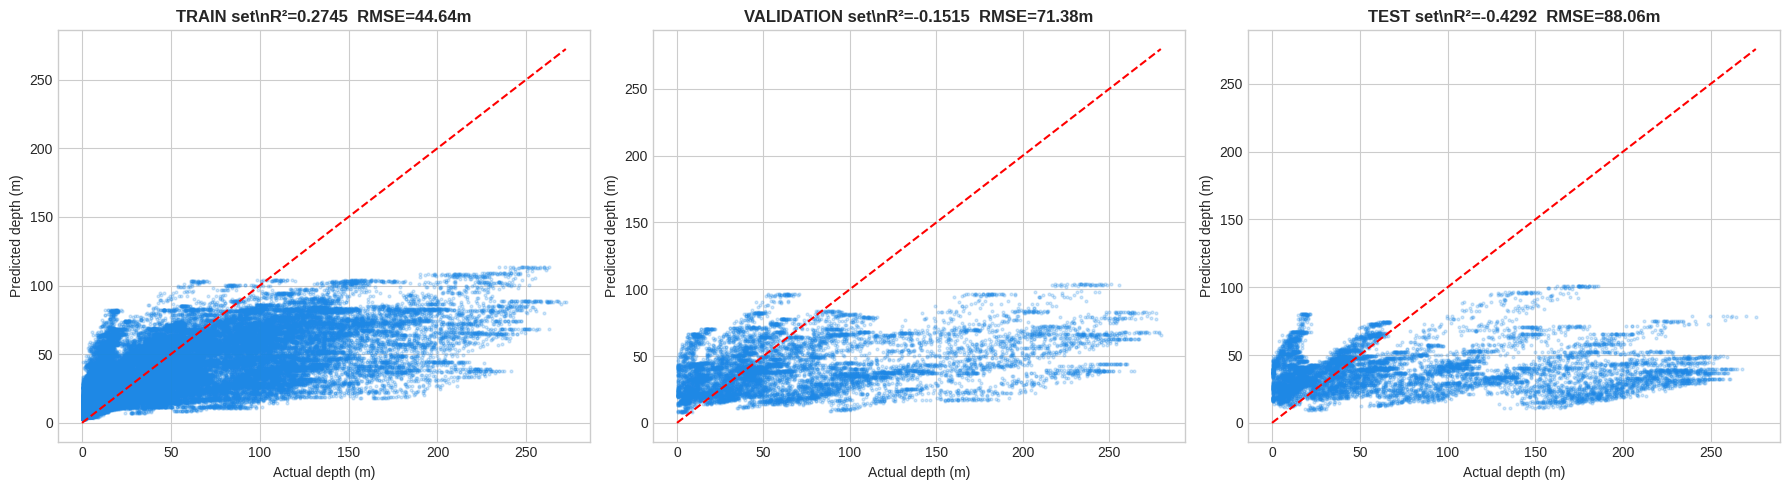

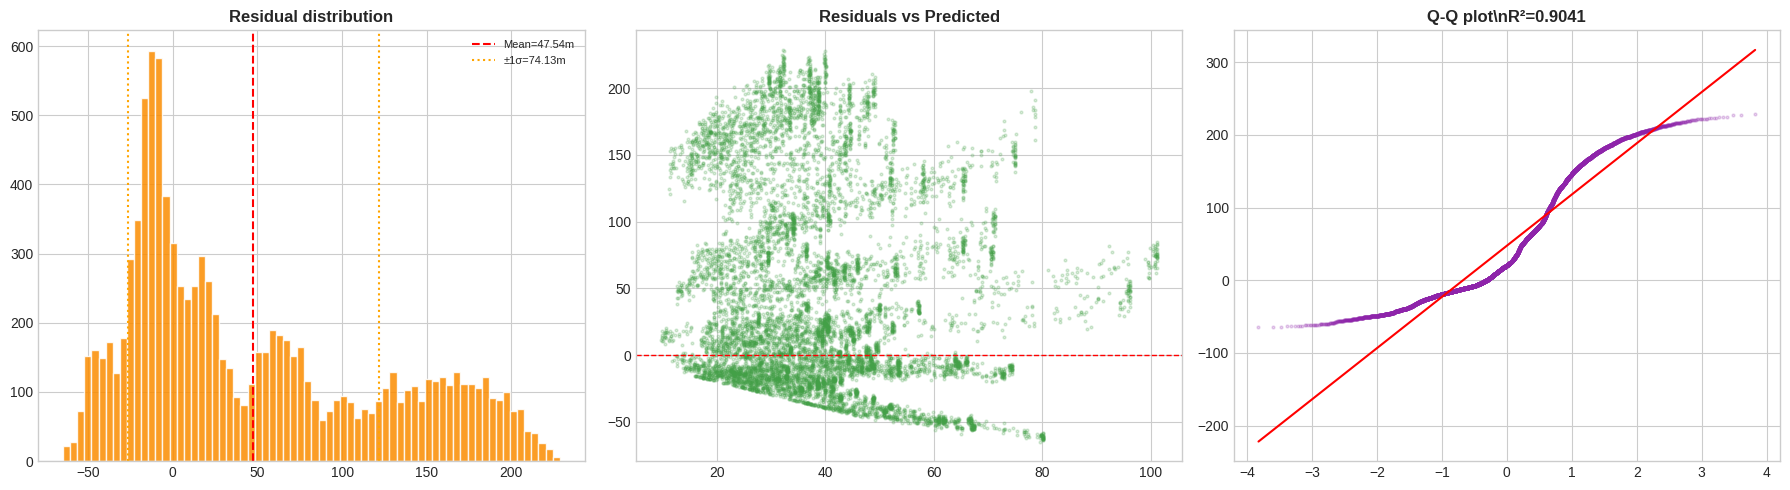

✅ Final model diagnostics saved


In [15]:
# 1. Update the model definition
best_params = search.best_params_.copy()
final_model = xgb.XGBRegressor(
    **best_params,
    early_stopping_rounds=50,  # <--- Move it here
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    objective='reg:squarederror',
    eval_metric='rmse',
)

print('Training final optimized model...')
t0 = time.time()

# 2. Update the fit call
final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
    # early_stopping_rounds=50,  <--- REMOVE this line from here
)

print(f'Training time: {time.time() - t0:.1f}s')

y_train_pred_final = inverse_transform(final_model.predict(X_train))
y_val_pred_final = inverse_transform(final_model.predict(X_val))
y_test_pred_final = inverse_transform(final_model.predict(X_test))

final_train = evaluate_predictions(y_train_raw.values, y_train_pred_final)
final_val = evaluate_predictions(y_val_raw.values, y_val_pred_final)
final_test = evaluate_predictions(y_test_raw.values, y_test_pred_final)

print('Final train:', final_train)
print('Final val  :', final_val)
print('Final test :', final_test)
print(f'Best iteration: {getattr(final_model, "best_iteration", None)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sets = [
    ('TRAIN', y_train_raw.values, y_train_pred_final, final_train),
    ('VALIDATION', y_val_raw.values, y_val_pred_final, final_val),
    ('TEST', y_test_raw.values, y_test_pred_final, final_test),
]
for idx, (name, y_true, y_pred, metrics) in enumerate(sets):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.2, s=4, color='#1E88E5', rasterized=True)
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
    ax.set_title(f'{name} set\\nR²={metrics['r2']:.4f}  RMSE={metrics['rmse']:.2f}m', fontweight='bold')
    ax.set_xlabel('Actual depth (m)')
    ax.set_ylabel('Predicted depth (m)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

residuals = y_test_raw.values - y_test_pred_final
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(residuals, bins=70, color='#FB8C00', edgecolor='white', alpha=0.85)
mu, sigma = residuals.mean(), residuals.std()
axes[0].axvline(mu, color='red', linestyle='--', label=f'Mean={mu:.2f}m')
axes[0].axvline(mu + sigma, color='orange', linestyle=':', label=f'±1σ={sigma:.2f}m')
axes[0].axvline(mu - sigma, color='orange', linestyle=':')
axes[0].set_title('Residual distribution', fontweight='bold')
axes[0].legend(fontsize=8)
axes[1].scatter(y_test_pred_final, residuals, alpha=0.2, s=4, color='#43A047', rasterized=True)
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
osm, osr = stats.probplot(residuals, dist='norm')[0]
slope, intercept, r = stats.probplot(residuals, dist='norm')[1]
axes[2].scatter(osm, osr, alpha=0.2, s=4, color='#8E24AA', rasterized=True)
axes[2].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
axes[2].set_title(f'Q-Q plot\\nR²={r**2:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final model diagnostics saved')

---
## 🌟 Step 8 — Feature Importance Analysis & Cross-Validation

Top 10 features by gain importance:
district_encoded      998.3517
rainfall_rolling_6m   770.5410
longitude             613.9531
month                 425.7240
season_encoded        296.4195
slope_degree          271.3440
temperature_avg       254.6528
soil_type_encoded     238.5717
elevation_m           227.1292
latitude              205.2822


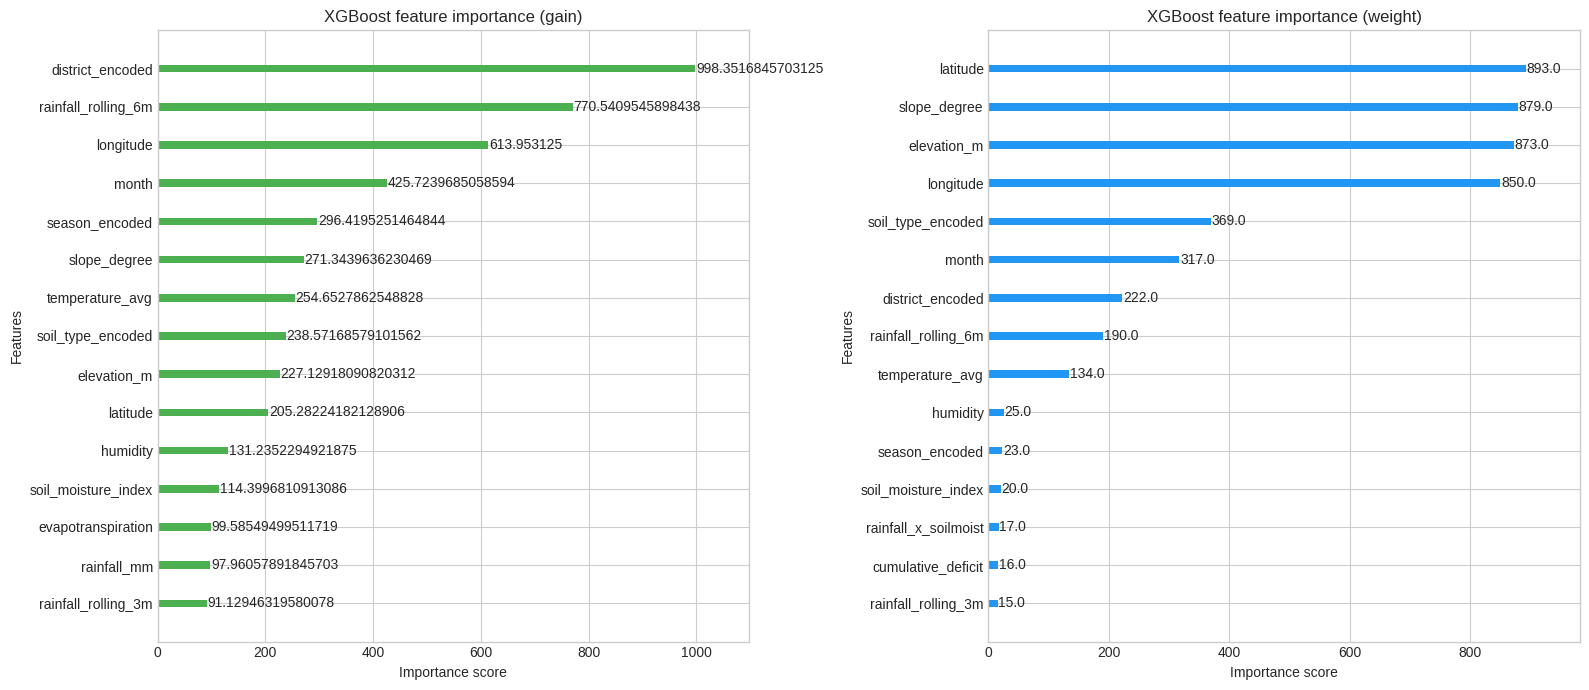

✅ Feature importance plot saved
Top 10 permutation importances:
month                  0.0219
rainfall_rolling_6m    0.0173
elevation_m            0.0148
soil_type_encoded      0.0121
temperature_avg        0.0055
humidity               0.0009
season_encoded         0.0006
rainfall_rolling_3m    0.0005
soil_moisture_index    0.0005
rainfall_x_soilmoist   0.0004
CV R² mean: -0.0273 ± 0.2127
CV RMSE mean: 1.1292


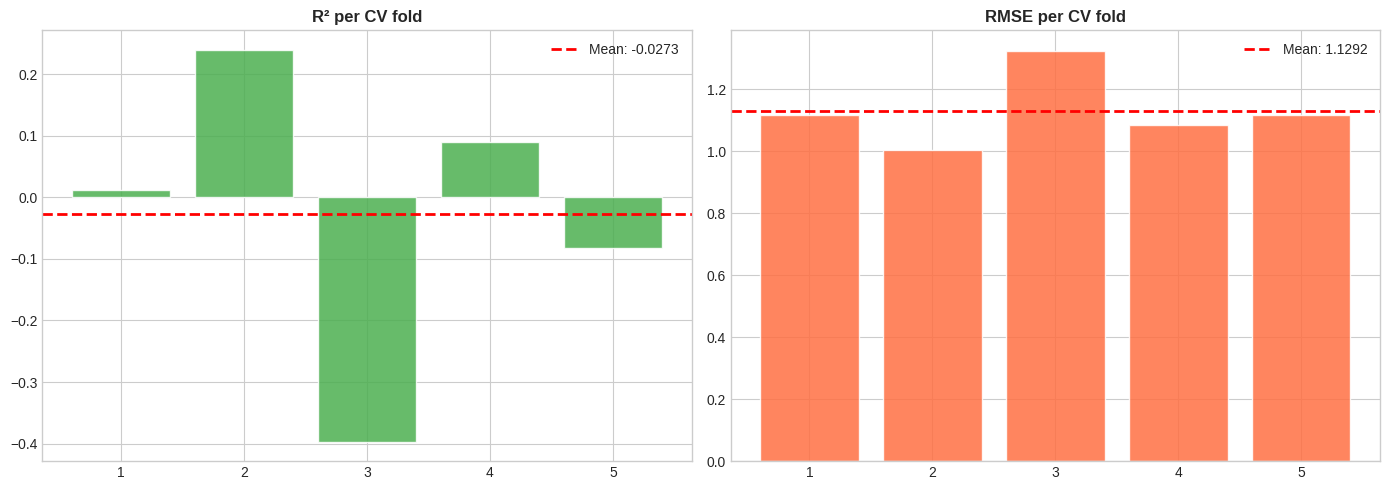

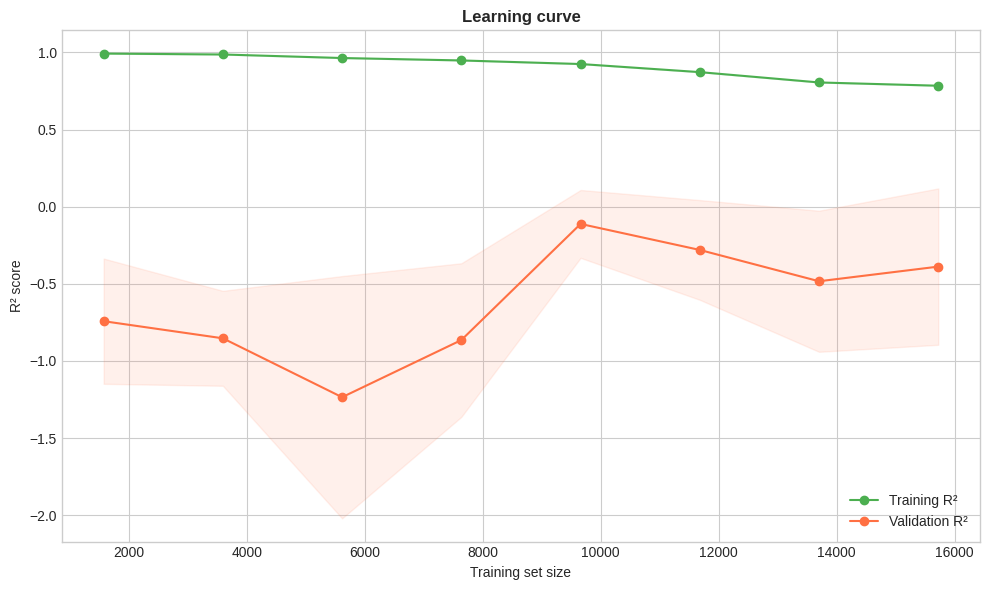

✅ Cross-validation and learning-curve plots saved


In [9]:
gain_scores = final_model.get_booster().get_score(importance_type='gain')
gain_series = pd.Series({feature: gain_scores.get(feature, 0.0) for feature in FEATURES}).sort_values(ascending=False)

print('Top 10 features by gain importance:')
print(gain_series.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
xgb.plot_importance(final_model, importance_type='gain', ax=axes[0], max_num_features=15, title='XGBoost feature importance (gain)', color='#4CAF50')
xgb.plot_importance(final_model, importance_type='weight', ax=axes[1], max_num_features=15, title='XGBoost feature importance (weight)', color='#2196F3')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plot saved')

perm = permutation_importance(final_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring='r2')
perm_series = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
print('Top 10 permutation importances:')
print(perm_series.head(10).to_string())

cv_model = xgb.XGBRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    objective='reg:squarederror',
    eval_metric='rmse',
)
ts_cv = TimeSeriesSplit(n_splits=5)
cv_scores_r2 = cross_val_score(cv_model, X_train, y_train, cv=ts_cv, scoring='r2', n_jobs=1)
cv_scores_rmse = cross_val_score(cv_model, X_train, y_train, cv=ts_cv, scoring='neg_root_mean_squared_error', n_jobs=1)
print(f'CV R² mean: {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}')
print(f'CV RMSE mean: {-cv_scores_rmse.mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = np.arange(1, 6)
axes[0].bar(folds, cv_scores_r2, color='#4CAF50', alpha=0.85, edgecolor='white')
axes[0].axhline(cv_scores_r2.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {cv_scores_r2.mean():.4f}')
axes[0].set_title('R² per CV fold', fontweight='bold')
axes[0].legend()
axes[1].bar(folds, -cv_scores_rmse, color='#FF7043', alpha=0.85, edgecolor='white')
axes[1].axhline(-cv_scores_rmse.mean(), color='red', linewidth=2, linestyle='--', label=f'Mean: {-cv_scores_rmse.mean():.4f}')
axes[1].set_title('RMSE per CV fold', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

train_sizes, train_scores, val_scores = learning_curve(
    cv_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=TimeSeriesSplit(n_splits=3),
    scoring='r2',
    n_jobs=1,
)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#4CAF50', label='Training R²')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#FF7043', label='Validation R²')
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1), train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='#4CAF50')
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1), val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='#FF7043')
ax.set_title('Learning curve', fontweight='bold')
ax.set_xlabel('Training set size')
ax.set_ylabel('R² score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Cross-validation and learning-curve plots saved')

---
## 🔮 Step 9 — Risk Classification & Inference

RISK CLASSIFICATION RESULTS (Test set)
Risk accuracy: 35.9%
              precision    recall  f1-score   support

        SAFE       0.36      0.38      0.37      3118
     WARNING       0.36      0.72      0.48      3541
    CRITICAL       1.00      0.01      0.03      2687
     EXTREME       0.00      0.00      0.00      1136

    accuracy                           0.36     10482
   macro avg       0.43      0.28      0.22     10482
weighted avg       0.48      0.36      0.28     10482



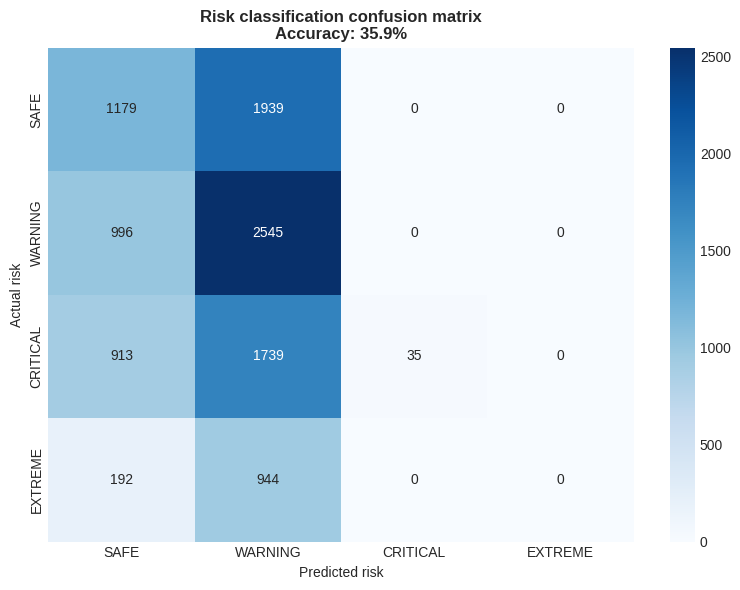

✅ Risk classification plot saved
Sample prediction: 78.61 m
Sample risk      : WARNING


In [11]:
def classify_risk(depth_m):
    if depth_m < 30:
        return 'SAFE'
    if depth_m < 100:
        return 'WARNING'
    if depth_m < 200:
        return 'CRITICAL'
    return 'EXTREME'

risk_order = ['SAFE', 'WARNING', 'CRITICAL', 'EXTREME']
y_true_risk = np.array([classify_risk(value) for value in y_test_raw.values])
y_pred_risk = np.array([classify_risk(value) for value in y_test_pred_final])
risk_accuracy = accuracy_score(y_true_risk, y_pred_risk)

print('=' * 72)
print('RISK CLASSIFICATION RESULTS (Test set)')
print('=' * 72)
print(f'Risk accuracy: {risk_accuracy * 100:.1f}%')
print(classification_report(y_true_risk, y_pred_risk, labels=risk_order, zero_division=0))

cm = confusion_matrix(y_true_risk, y_pred_risk, labels=risk_order)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=risk_order, yticklabels=risk_order, ax=ax)
ax.set_title(f'Risk classification confusion matrix\nAccuracy: {risk_accuracy * 100:.1f}%', fontweight='bold')
ax.set_xlabel('Predicted risk')
ax.set_ylabel('Actual risk')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_risk_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Risk classification plot saved')

sample_input = X_test.iloc[[0]].copy()
sample_prediction_log = final_model.predict(sample_input)[0]
sample_prediction = float(np.expm1(sample_prediction_log))
print(f'Sample prediction: {sample_prediction:.2f} m')
print(f'Sample risk      : {classify_risk(sample_prediction)}')

---
## 💾 Step 10 — Save Model & Artifacts

In [12]:
version_str = datetime.now().strftime('%Y%m%d_%H%M%S')
model_hash = hashlib.md5(str(best_params).encode()).hexdigest()[:8]
MODEL_PATH = MODEL_DIR / 'xgboost_no_lag_best.pkl'
VERSIONED_MODEL_PATH = MODEL_DIR / f'xgboost_no_lag_{version_str}_{model_hash}.pkl'
NATIVE_MODEL_PATH = MODEL_DIR / 'xgboost_no_lag_best.json'
CONFIG_PATH = MODEL_DIR / 'xgboost_no_lag_config.json'
METRICS_PATH = MODEL_DIR / 'xgboost_no_lag_metrics.json'

joblib.dump(final_model, MODEL_PATH)
joblib.dump(final_model, VERSIONED_MODEL_PATH)
final_model.save_model(NATIVE_MODEL_PATH)

feature_groups = {
    'Meteorological': ['rainfall_mm', 'temperature_avg', 'temperature_max_c', 'temperature_min_c', 'humidity', 'evapotranspiration', 'evapotranspiration_mm'],
    'Soil & Hydrology': ['soil_moisture_index', 'runoff_mm', 'baseflow_mm', 'soil_type_encoded'],
    'Rolling Statistics': ['rainfall_rolling_3m', 'rainfall_rolling_6m'],
    'Stress Indicators': ['rainfall_deficit', 'cumulative_deficit', 'temp_rainfall_ratio', 'drought_index', 'irrigation_demand_mm', 'water_stress_index'],
    'Temporal': ['month', 'season_encoded', 'season', 'month_sin', 'month_cos'],
    'Geospatial': ['latitude', 'longitude', 'elevation_m', 'slope_degree', 'district_encoded'],
    'Vegetation': ['ndvi'],
    'Engineered': ['rainfall_x_soilmoist'],
}

config = {
    'base_path': str(BASE_PATH),
    'data_path': str(DATA_PATH),
    'feature_columns': FEATURES,
    'target_column': TARGET,
    'target_transform': 'log1p',
    'inverse_transform': 'expm1',
    'excluded_columns': sorted(list(DROP_COLUMNS)),
    'excluded_patterns': ['lag', 'depth_change_rate'],
    'feature_groups': feature_groups,
    'split_strategy': '75% train / 12.5% val / 12.5% test by row index',
}
with open(CONFIG_PATH, 'w', encoding='utf-8') as handle:
    json.dump(config, handle, indent=2)

metrics = {
    'model': 'XGBRegressor',
    'model_version': f'{version_str}_{model_hash}',
    'best_params': best_params,
    'best_cv_r2': float(search.best_score_),
    'baseline_test': baseline_test,
    'final_train': final_train,
    'final_val': final_val,
    'final_test': final_test,
    'risk_accuracy_pct': float(risk_accuracy * 100),
    'cv_r2_mean': float(cv_scores_r2.mean()),
    'cv_r2_std': float(cv_scores_r2.std()),
    'train_rows': int(len(X_train)),
    'val_rows': int(len(X_val)),
    'test_rows': int(len(X_test)),
    'feature_count': int(len(FEATURES)),
    'trained_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}
with open(METRICS_PATH, 'w', encoding='utf-8') as handle:
    json.dump(metrics, handle, indent=2, default=str)

fi_df = pd.DataFrame({
    'feature': FEATURES,
    'gain_importance': [gain_scores.get(feature, 0.0) for feature in FEATURES],
    'permutation_importance': perm_series.reindex(FEATURES).fillna(0.0).values,
}).sort_values('gain_importance', ascending=False)
fi_df.to_csv(OUTPUT_DIR / 'xgboost_feature_importances.csv', index=False)

print('Saved artifacts:')
print(f'  Model   : {MODEL_PATH}')
print(f'  Native  : {NATIVE_MODEL_PATH}')
print(f'  Version : {VERSIONED_MODEL_PATH}')
print(f'  Config  : {CONFIG_PATH}')
print(f'  Metrics : {METRICS_PATH}')
print(f'  Output plots stored in: {OUTPUT_DIR}')

Saved artifacts:
  Model   : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/xgboost_no_lag_best.pkl
  Native  : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/xgboost_no_lag_best.json
  Version : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/xgboost_no_lag_20260507_143735_4daa4324.pkl
  Config  : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/xgboost_no_lag_config.json
  Metrics : /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/saved_models/xgboost_no_lag_metrics.json
  Output plots stored in: /content/drive/MyDrive/WPS_PRO/Models/engines/path1_temporal/outputs/xgboost_no_lag


---
## 📋 Step 11 — Final Summary

In [13]:
print('\n' + '═' * 72)
print('            XGBOOST TEMPORAL ENGINE — FINAL SUMMARY')
print('═' * 72)
print(f'Features used : {len(FEATURES)}')
print(f'Train rows    : {len(X_train):,}')
print(f'Val rows      : {len(X_val):,}')
print(f'Test rows     : {len(X_test):,}')
print(f'Best CV R²    : {search.best_score_:.4f}')
print(f'Test R²       : {final_test['r2']:.4f}')
print(f'Test RMSE     : {final_test['rmse']:.2f} m')
print(f'Test MAE      : {final_test['mae']:.2f} m')
print(f'Test MdAPE    : {final_test['mdape']:.2f}%')
print(f'Risk accuracy : {risk_accuracy * 100:.1f}%')
print('═' * 72)
print('Notebook is complete and all artifacts were saved to Google Drive paths when available.')


════════════════════════════════════════════════════════════════════════
            XGBOOST TEMPORAL ENGINE — FINAL SUMMARY
════════════════════════════════════════════════════════════════════════
Features used : 20
Train rows    : 62,887
Val rows      : 10,481
Test rows     : 10,482
Best CV R²    : -0.0273
Test R²       : -0.4292
Test RMSE     : 88.06 m
Test MAE      : 63.02 m
Test MdAPE    : 71.82%
Risk accuracy : 35.9%
════════════════════════════════════════════════════════════════════════
Notebook is complete and all artifacts were saved to Google Drive paths when available.
